<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/99424_LAB_ACTIVITY1_DAY2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import Library ที่ต้องใช้
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Ready for Reinforcement Learning Lab 1")

# Cell 2: กำหนดขนาดตาราง และสร้างฟังก์ชันแปลง State
N = 4 # ขนาดตาราง 4x4

def to_rc(state):
    row = state // N   # หารเอาส่วน เพื่อหาว่าอยู่แถวไหน (0, 1, 2, 3)
    col = state % N    # หารเอาเศษ เพื่อหาว่าอยู่คอลัมน์ไหน (0, 1, 2, 3)
    return row, col

def to_state(row, col):
    state = row * N + col # แปลงพิกัดแถว/คอลัมน์ กลับมาเป็นเลข State ตัวเดียว (0-15)
    return state

Ready for Reinforcement Learning Lab 1


In [ ]:
print("State 0  =", to_rc(0))
print("State 6  =", to_rc(6))
print("State 10 =", to_rc(10))
print("State 15 =", to_rc(15))
print("Row 2, Col 3 =", to_state(2, 3))
print("Row 3, Col 2 =", to_state(3, 2))

State 0  = (0, 0)
State 6  = (1, 2)
State 10 = (2, 2)
State 15 = (3, 3)
Row 2, Col 3 = 11
Row 3, Col 2 = 14


In [ ]:
# Cell 4-5: กำหนดทิศทาง และฟังก์ชันการเดิน
ACTIONS = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}

def move(state, action):
    row, col = to_rc(state)

    if action == 0:     # ซ้าย
        col = max(0, col - 1)
    elif action == 1:   # ลง
        row = min(N-1, row + 1)
    elif action == 2:   # ขวา
        col = min(N-1, col + 1)
    elif action == 3:   # ขึ้น
        row = max(0, row - 1)

    return to_state(row, col)

# Cell 8-9: กำหนดเงื่อนไขของ Environment (หลุม และ เป้าหมาย)
START = 0
GOAL = 15
HOLES = {5, 7, 11, 12} # ตําแหน่งหลุม

def step_env(state, action):
    new_state = move(state, action)

    if new_state in HOLES:
        reward = -1     # ตกหลุม โดนหักคะแนน
        done = True     # จบเกม (Game Over)
    elif new_state == GOAL:
        reward = 1      # ชนะ ได้แต้ม
        done = True     # จบเกม (Win)
    else:
        reward = 0      # ช่องปกติ เดินต่อได้
        done = False

    return new_state, reward, done

In [ ]:
# Cell 7: ทดลองเดินชนขอบตาราง
state = 0
print("Old state:", state)


state = move(state, 3)
print("Action:", state)


state = move(state, 0)
print("New state:", state)

Old state: 0
Action: 0
New state: 0


In [ ]:
state = 0

print("Start state:", state)

state = move(state, 2)
print("After Right:", state)

state = move(state, 1)
print("After Down:", state)

state = move(state, 2)
print("After Right:", state)

Start state: 0
After Right: 1
After Down: 5
After Right: 6


In [ ]:
# Cell 10: ทดลองเดินไปช่องปกติ

state = 0
action = 2

new_state, reward, done = step_env(state, action)

print("Old state:", state)
print("Action:", ACTIONS[action])
print("New state:", new_state)

print("Reward:", reward)
print("Done:", done)


Old state: 0
Action: Right
New state: 1
Reward: 0
Done: False


In [ ]:
# Cell 10: ลองเดินไปช่องตกหลุม

state = 1
action = 1

new_state, reward, done = step_env(state, action)

print("Old state:", state)
print("Action:", ACTIONS[action])
print("New state:", new_state)

print("Reward:", reward)
print("Done:", done)

Old state: 1
Action: Down
New state: 5
Reward: -1
Done: True


In [ ]:
# Cell 10: ลองเดินไปถึง GOAL

state = 14
action = 2

new_state, reward, done = step_env(state, action)

print("Old state:", state)
print("Action:", ACTIONS[action])
print("New state:", new_state)

print("Reward:", reward)
print("Done:", done)


Old state: 14
Action: Right
New state: 15
Reward: 1
Done: True


In [ ]:
# Cell 11: ฟังก์ชันสำหรับแสดงกราฟิกของตาราง
def plot_grid(path=None, title="Grid World"):
    fig, ax = plt.subplots(figsize=(5, 5))

    for r in range(N):
        for c in range(N):
            state = to_state(r, c)
            # วาดบล็อกสี่เหลี่ยมแต่ละช่อง
            rect = patches.Rectangle((c, r), 1, 1, fill=False, linewidth=1.5)
            ax.add_patch(rect)

            # ใส่ตัวอักษรกำกับในช่อง
            if state == START:
                label = "S\n0"
            elif state == GOAL:
                label = "G\n15"
            elif state == HOLES: # ตรวจสอบค่าใน set
                label = "H\n" + str(state)
            elif state in HOLES:
                label = "H\n" + str(state)
            else:
                label = str(state)

            ax.text(c + 0.5, r + 0.5, label, ha="center", va="center", fontsize=13)

    # ถ้ามีการส่งประวัติเส้นทางการเดิน (path) มา ให้ลากเส้นน้ำเงินเชื่อมต่อ
    if path is not None:
        xs = []
        ys = []
        for s in path:
            r, c = to_rc(s)
            xs.append(c + 0.5)
            ys.append(r + 0.5)
        ax.plot(xs, ys, marker="o", linewidth=2, color="blue")

    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.invert_yaxis() # พลิกแกน Y ให้แถว 0 อยู่ด้านบนสุด
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()

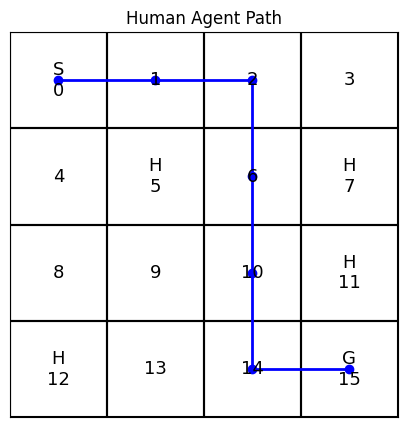

In [ ]:
# Cell 13
state = START
path = [state]
manual_actions = [2, 2, 1, 1, 1, 2] # ขวา -> ขวา -> ลง -> ลง -> ลง -> ขวา

for action in manual_actions:
    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    state = new_state
    if done: break

plot_grid(path, title="Human Agent Path")

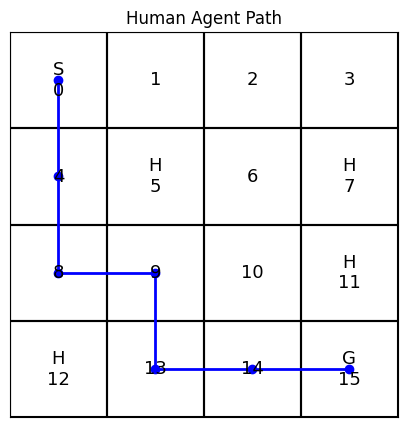

In [ ]:
# Cell 13
state = START
path = [state]
#manual_actions = [2, 2, 1, 1, 1, 2] # ขวา -> ขวา -> ลง -> ลง -> ลง -> ขวา
manual_actions = [1, 1, 2, 1, 2, 2] #
#manual_actions = [1, 1, 2, 2, 1, 1, 2] #

for action in manual_actions:
    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    state = new_state
    if done: break

plot_grid(path, title="Human Agent Path")

Step 1: Action = Down | State = 4 | Reward = 0 | Done = False
Step 2: Action = Up | State = 0 | Reward = 0 | Done = False
Step 3: Action = Left | State = 0 | Reward = 0 | Done = False
Step 4: Action = Up | State = 0 | Reward = 0 | Done = False
Step 5: Action = Right | State = 1 | Reward = 0 | Done = False
Step 6: Action = Down | State = 5 | Reward = -1 | Done = True
Random Agent Path: [0, 4, 0, 0, 0, 1, 5]


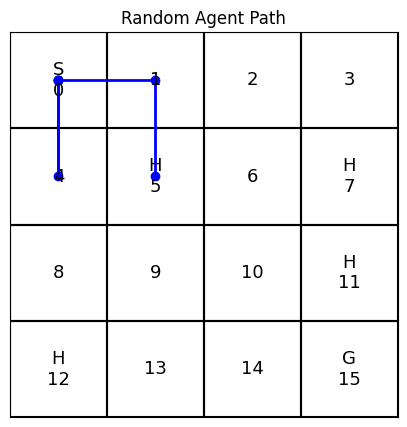

In [ ]:
state = START
path = [state]
max_steps = 20

for step in range(max_steps):
    action = np.random.randint(0, 4)			# สุ่ม Action 0-3
    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    state = new_state
    print(
        f"Step {step + 1}:",
        "Action =", ACTIONS[action],
        "| State =", state,
        "| Reward =", reward,
        "| Done =", done
    )

    if done: break

print("Random Agent Path:", path)
plot_grid(path, title="Random Agent Path")


Step 1: Action = Down | State = 4 | Reward = 0 | Done = False
Step 2: Action = Up | State = 0 | Reward = 0 | Done = False
Step 3: Action = Left | State = 0 | Reward = 0 | Done = False
Step 4: Action = Left | State = 0 | Reward = 0 | Done = False
Step 5: Action = Down | State = 4 | Reward = 0 | Done = False
Step 6: Action = Up | State = 0 | Reward = 0 | Done = False
Step 7: Action = Up | State = 0 | Reward = 0 | Done = False
Step 8: Action = Left | State = 0 | Reward = 0 | Done = False
Step 9: Action = Right | State = 1 | Reward = 0 | Done = False
Step 10: Action = Left | State = 0 | Reward = 0 | Done = False
Step 11: Action = Left | State = 0 | Reward = 0 | Done = False
Step 12: Action = Down | State = 4 | Reward = 0 | Done = False
Step 13: Action = Right | State = 5 | Reward = -1 | Done = True
Random Agent Path: [0, 4, 0, 0, 0, 4, 0, 0, 0, 1, 0, 0, 4, 5]


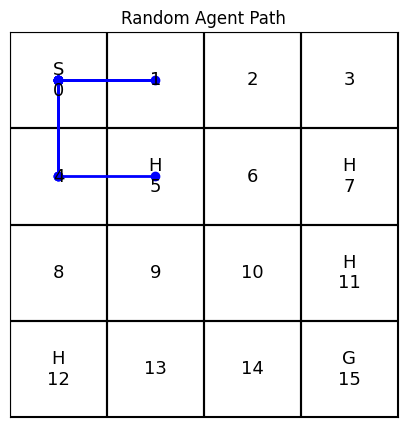

In [ ]:
state = START
path = [state]
max_steps = 20

for step in range(max_steps):
    action = np.random.randint(0, 4)			# สุ่ม Action 0-3
    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    state = new_state
    print(
        f"Step {step + 1}:",
        "Action =", ACTIONS[action],
        "| State =", state,
        "| Reward =", reward,
        "| Done =", done
    )

    if done: break

print("Random Agent Path:", path)
plot_grid(path, title="Random Agent Path")


Step 1: Action = Right | State = 1 | Reward = 0 | Done = False
Step 2: Action = Down | State = 5 | Reward = -1 | Done = True
Random Agent Path: [0, 1, 5]


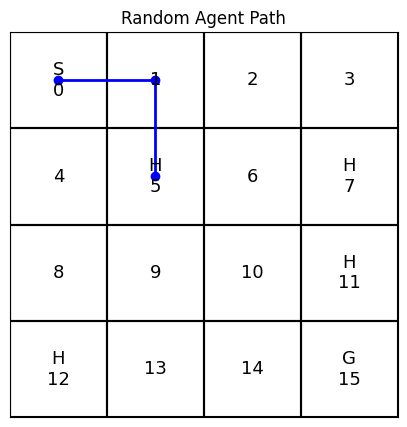

In [ ]:
state = START
path = [state]
max_steps = 20

for step in range(max_steps):
    action = np.random.randint(0, 4)			# สุ่ม Action 0-3
    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    state = new_state
    print(
        f"Step {step + 1}:",
        "Action =", ACTIONS[action],
        "| State =", state,
        "| Reward =", reward,
        "| Done =", done
    )

    if done: break

print("Random Agent Path:", path)
plot_grid(path, title="Random Agent Path")


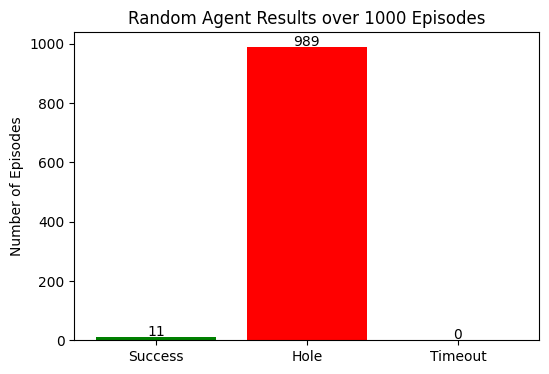

Success Rate: 1.0999999999999999%


In [ ]:
# Cell 15-16: รันบอทสุ่ม 1,000 รอบ
success_count = 0
hole_count = 0
timeout_count = 0
episodes = 1000
max_steps = 50

for ep in range(episodes):
    state = START
    for step in range(max_steps):
        action = np.random.randint(0, 4) # สุ่มเลข 0, 1, 2, 3
        new_state, reward, done = step_env(state, action)
        state = new_state

        if done:
            if state == GOAL:
                success_count += 1
            elif state in HOLES:
                hole_count += 1
            break
    else:
        timeout_count += 1 # เดินครบ 50 ก้าวแล้วยังไม่จบเกม

# วาดกราฟแท่งสรุปสถิติ
labels = ["Success", "Hole", "Timeout"]
values = [success_count, hole_count, timeout_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red', 'orange'])
plt.title("Random Agent Results over 1000 Episodes")
plt.ylabel("Number of Episodes")
for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(f"Success Rate: {success_count / episodes * 100}%")

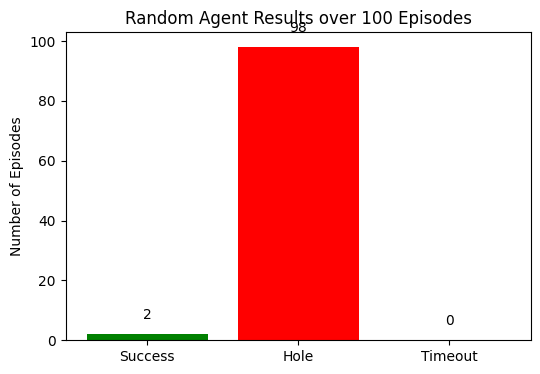

Success Rate: 2.0%


In [ ]:
# Cell 15-16: รันบอทสุ่ม 100 รอบ
success_count = 0
hole_count = 0
timeout_count = 0
episodes = 100
max_steps = 50

for ep in range(episodes):
    state = START
    for step in range(max_steps):
        action = np.random.randint(0, 4) # สุ่มเลข 0, 1, 2, 3
        new_state, reward, done = step_env(state, action)
        state = new_state

        if done:
            if state == GOAL:
                success_count += 1
            elif state in HOLES:
                hole_count += 1
            break
    else:
        timeout_count += 1 # เดินครบ 50 ก้าวแล้วยังไม่จบเกม

# วาดกราฟแท่งสรุปสถิติ
labels = ["Success", "Hole", "Timeout"]
values = [success_count, hole_count, timeout_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red', 'orange'])
plt.title("Random Agent Results over 100 Episodes")
plt.ylabel("Number of Episodes")
for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(f"Success Rate: {success_count / episodes * 100}%")

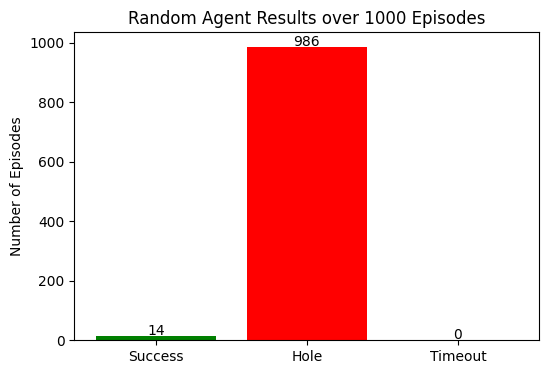

Success Rate: 1.4000000000000001%


In [ ]:
# Cell 15-16: รันบอทสุ่ม 1000 รอบ
success_count = 0
hole_count = 0
timeout_count = 0
episodes = 1000
max_steps = 50

for ep in range(episodes):
    state = START
    for step in range(max_steps):
        action = np.random.randint(0, 4) # สุ่มเลข 0, 1, 2, 3
        new_state, reward, done = step_env(state, action)
        state = new_state

        if done:
            if state == GOAL:
                success_count += 1
            elif state in HOLES:
                hole_count += 1
            break
    else:
        timeout_count += 1 # เดินครบ 50 ก้าวแล้วยังไม่จบเกม

# วาดกราฟแท่งสรุปสถิติ
labels = ["Success", "Hole", "Timeout"]
values = [success_count, hole_count, timeout_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red', 'orange'])
plt.title("Random Agent Results over 1000 Episodes")
plt.ylabel("Number of Episodes")
for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(f"Success Rate: {success_count / episodes * 100}%")

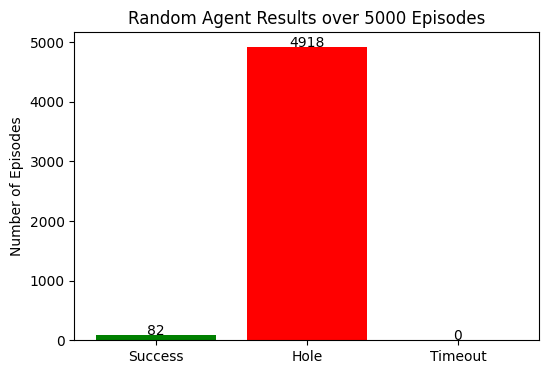

Success Rate: 1.6400000000000001%


In [ ]:
# Cell 15-16: รันบอทสุ่ม 5000 รอบ
success_count = 0
hole_count = 0
timeout_count = 0
episodes = 5000
max_steps = 50

for ep in range(episodes):
    state = START
    for step in range(max_steps):
        action = np.random.randint(0, 4) # สุ่มเลข 0, 1, 2, 3
        new_state, reward, done = step_env(state, action)
        state = new_state

        if done:
            if state == GOAL:
                success_count += 1
            elif state in HOLES:
                hole_count += 1
            break
    else:
        timeout_count += 1 # เดินครบ 50 ก้าวแล้วยังไม่จบเกม

# วาดกราฟแท่งสรุปสถิติ
labels = ["Success", "Hole", "Timeout"]
values = [success_count, hole_count, timeout_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red', 'orange'])
plt.title("Random Agent Results over 5000 Episodes")
plt.ylabel("Number of Episodes")
for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(f"Success Rate: {success_count / episodes * 100}%")

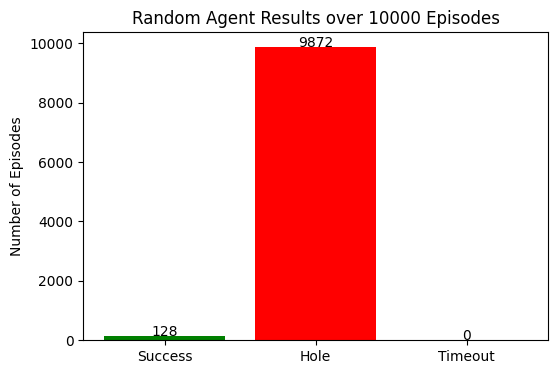

Success Rate: 1.28%


In [ ]:
# Cell 15-16: รันบอทสุ่ม 5000 รอบ
success_count = 0
hole_count = 0
timeout_count = 0
episodes = 10000
max_steps = 50

for ep in range(episodes):
    state = START
    for step in range(max_steps):
        action = np.random.randint(0, 4) # สุ่มเลข 0, 1, 2, 3
        new_state, reward, done = step_env(state, action)
        state = new_state

        if done:
            if state == GOAL:
                success_count += 1
            elif state in HOLES:
                hole_count += 1
            break
    else:
        timeout_count += 1 # เดินครบ 50 ก้าวแล้วยังไม่จบเกม

# วาดกราฟแท่งสรุปสถิติ
labels = ["Success", "Hole", "Timeout"]
values = [success_count, hole_count, timeout_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red', 'orange'])
plt.title("Random Agent Results over 10000 Episodes")
plt.ylabel("Number of Episodes")
for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(f"Success Rate: {success_count / episodes * 100}%")